<a href="https://colab.research.google.com/github/tombraganca/Topicos-em-Computacao-III/blob/main/AS03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

# Por algum motivo eu não consegui instalar o gensim corretamente. Procurei por
# Todos os ambientes, versoes e solucoes possiveis mas pelo visto é algo do colab

# ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
# thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
# Successfully installed gensim-4.3.3 numpy-1.26.4 scipy-1.13.1

In [ ]:
# 📁 Imports principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, manhattan_distances, euclidean_distances
from scipy.spatial.distance import minkowski, jaccard
# from gensim.models import Word2Vec
from collections import Counter
import os

In [ ]:
# 📂 Lê as headlines (coloque o caminho correto caso use um arquivo)
sentences = [
    "Investors unfazed by correction as crypto funds see $154 million inflows.",
    "Bitcoin, Ethereum prices continue descent, but crypto funds see inflows.",
    "The surge in euro area inflation during the pandemic: transitory but with upside risks.",
    "Inflation: why it's temporary and raising interest rates will do more harm than good.",
    "Will Cryptocurrency Protect Against Inflation?",
    "Tweed is a crypto wallet API to add a web3 flavor to any web service.",
    "Who Created Bitcoin?",
    "Learn About The Biggest Cryptos, Including Dogecoin, Big Eyes Coin.",
    "Cryptocurrency Prices And News: Bitcoin, Cryptos Fall After Silvergate Bank Liquidation News.",
    "Silvergate Capital To Shut Down, Liquidate Crypto-Friendly Silvergate Bank.",
    "Dow Jones Rises On Surprise Jump In Jobless Claims;",
    "Bitcoin Drops As Crypto Bank Silvergate Crashes 40%."
]

# 🔤 Pré-processamento
sentences = [s.lower() for s in sentences]
entries = [s.split() for s in sentences]



In [ ]:
def vectorize_one_hot(entries):
    vocab = sorted(set(word for doc in entries for word in doc))
    vocab_index = {word: idx for idx, word in enumerate(vocab)}
    vectors = np.zeros((len(entries), len(vocab)))
    for i, doc in enumerate(entries):
        for word in set(doc):
            vectors[i, vocab_index[word]] = 1
    return vectors

def vectorize_count(sentences):
    return CountVectorizer().fit_transform(sentences).toarray()

def vectorize_tfidf(sentences):
    return TfidfVectorizer().fit_transform(sentences).toarray()

def vectorize_ngrams(sentences):
    return CountVectorizer(ngram_range=(2, 2)).fit_transform(sentences).toarray()

def vectorize_cooccurrence(entries, window_size=1):
    vocab = sorted(set(word for doc in entries for word in doc))
    vocab_index = {word: idx for idx, word in enumerate(vocab)}
    co_matrix = np.zeros((len(entries), len(vocab)))
    for i, doc in enumerate(entries):
        counter = Counter()
        for j, word in enumerate(doc):
            for offset in range(-window_size, window_size + 1):
                if offset == 0:
                    continue
                k = j + offset
                if 0 <= k < len(doc):
                    counter[doc[k]] += 1
        for word, count in counter.items():
            co_matrix[i, vocab_index[word]] = count
    return co_matrix

def vectorize_word2vec(entries, size=50):
    model = Word2Vec(sentences=entries, vector_size=size, window=2, min_count=1, workers=1, epochs=100)
    vectors = []
    for doc in entries:
        vecs = [model.wv[word] for word in doc if word in model.wv]
        if vecs:
            vectors.append(np.mean(vecs, axis=0))
        else:
            vectors.append(np.zeros(size))
    return np.array(vectors)

In [ ]:
def compute_similarity(matrix, metric):
    if metric == "cosine":
        return cosine_similarity(matrix)
    elif metric == "manhattan":
        return -manhattan_distances(matrix)
    elif metric == "euclidean":
        return -euclidean_distances(matrix)
    elif metric == "minkowski":
        n = matrix.shape[0]
        result = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                result[i, j] = -minkowski(matrix[i], matrix[j], p=3)
        return result
    elif metric == "jaccard":
        n = matrix.shape[0]
        result = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                result[i, j] = -jaccard(matrix[i], matrix[j])
        return result
    else:
        raise ValueError("Métrica desconhecida")

In [ ]:

def create_heatmap(sim_matrix, title, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(sim_matrix, xticklabels=range(1, len(sim_matrix)+1), yticklabels=range(1, len(sim_matrix)+1),
                cmap='viridis', annot=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"heatmaps/{filename}.png")
    plt.close()

In [ ]:
vectors = {
    "one_hot": vectorize_one_hot(entries),
    "count": vectorize_count(sentences),
    "tfidf": vectorize_tfidf(sentences),
    "2gram": vectorize_ngrams(sentences),
    "cooccurrence": vectorize_cooccurrence(entries),
}

metrics = ["cosine", "manhattan", "euclidean", "minkowski", "jaccard"]

In [ ]:
os.makedirs("heatmaps", exist_ok=True)

In [ ]:

for vec_name, vec_data in vectors.items():
    for metric in metrics:
        try:
            sim = compute_similarity(vec_data, metric)
            filename = f"{vec_name}_{metric}"
            title = f"{vec_name.upper()} + {metric.upper()}"
            create_heatmap(sim, title, filename)
            print(f"✅ Mapa gerado: {filename}.png")
        except Exception as e:
            print(f"❌ Erro ao gerar {vec_name} + {metric}: {e}")

✅ Mapa gerado: one_hot_cosine.png
✅ Mapa gerado: one_hot_manhattan.png
✅ Mapa gerado: one_hot_euclidean.png
✅ Mapa gerado: one_hot_minkowski.png
✅ Mapa gerado: one_hot_jaccard.png
✅ Mapa gerado: count_cosine.png
✅ Mapa gerado: count_manhattan.png
✅ Mapa gerado: count_euclidean.png
✅ Mapa gerado: count_minkowski.png
✅ Mapa gerado: count_jaccard.png
✅ Mapa gerado: tfidf_cosine.png
✅ Mapa gerado: tfidf_manhattan.png
✅ Mapa gerado: tfidf_euclidean.png
✅ Mapa gerado: tfidf_minkowski.png
✅ Mapa gerado: tfidf_jaccard.png
✅ Mapa gerado: 2gram_cosine.png
✅ Mapa gerado: 2gram_manhattan.png
✅ Mapa gerado: 2gram_euclidean.png
✅ Mapa gerado: 2gram_minkowski.png
✅ Mapa gerado: 2gram_jaccard.png
✅ Mapa gerado: cooccurrence_cosine.png
✅ Mapa gerado: cooccurrence_manhattan.png
✅ Mapa gerado: cooccurrence_euclidean.png
✅ Mapa gerado: cooccurrence_minkowski.png
✅ Mapa gerado: cooccurrence_jaccard.png


🖼️ Exibindo 25 mapas de calor...

📌 2gram_cosine.png


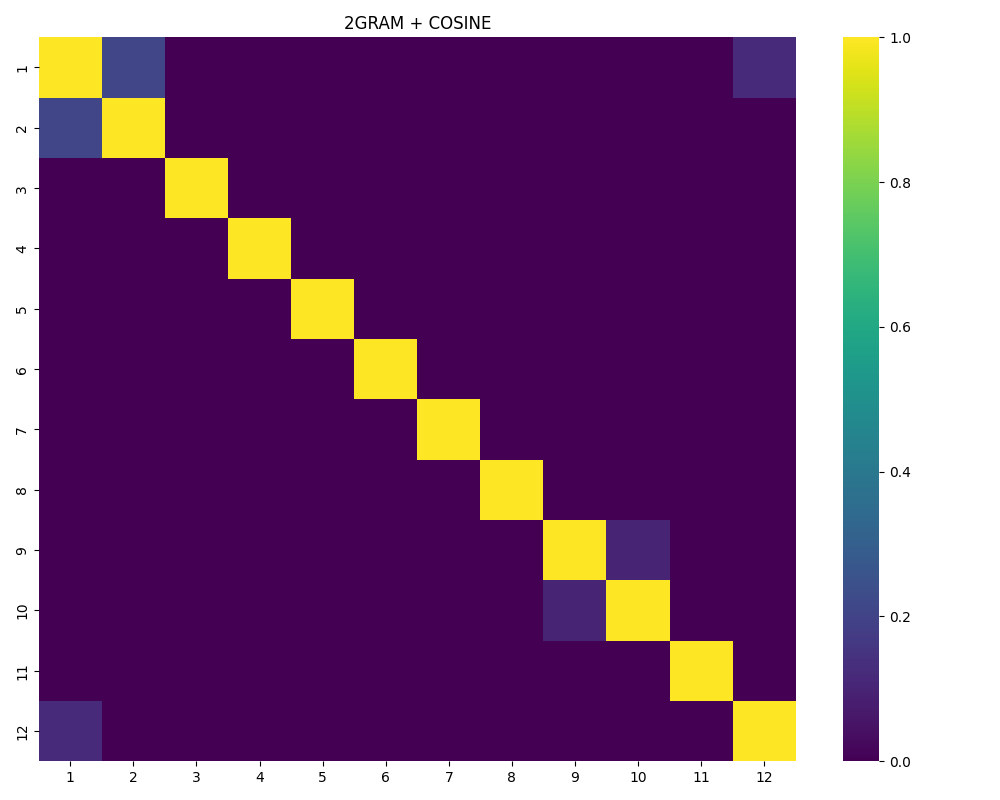

📌 2gram_euclidean.png


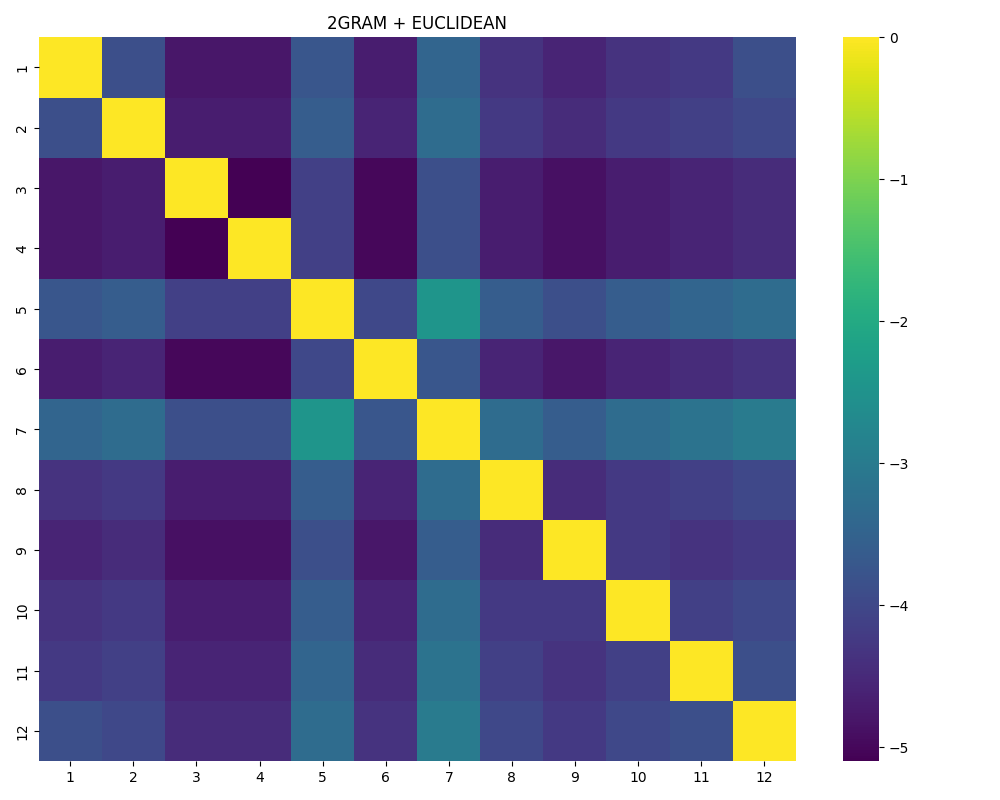

📌 2gram_jaccard.png


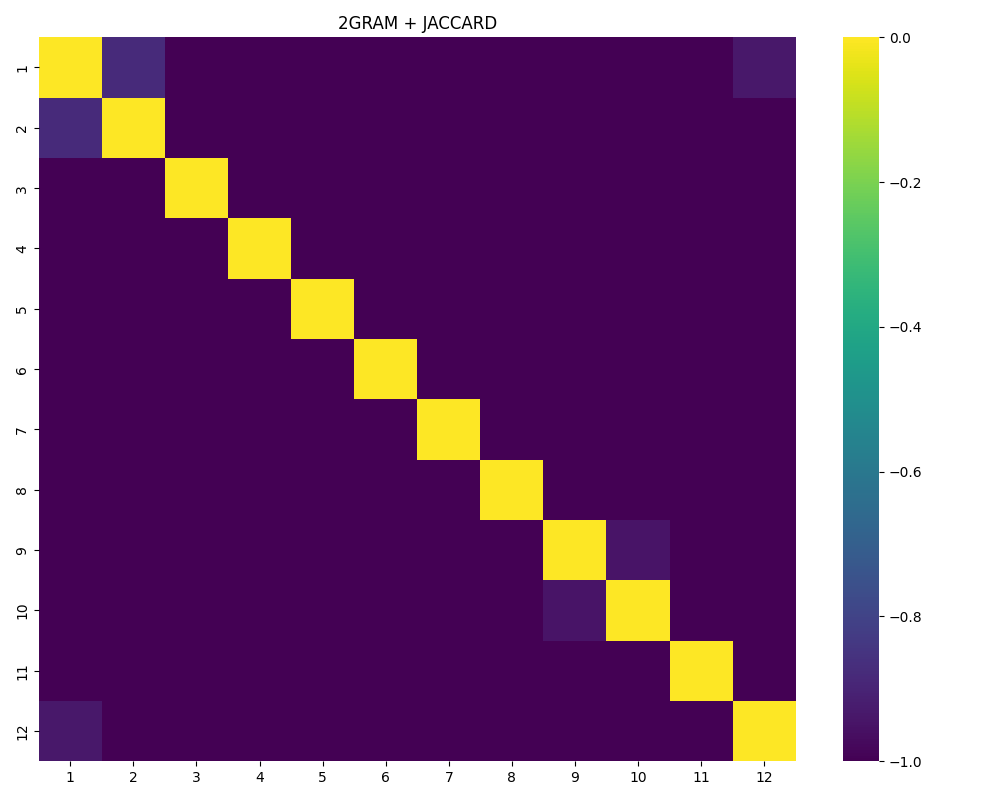

📌 2gram_manhattan.png


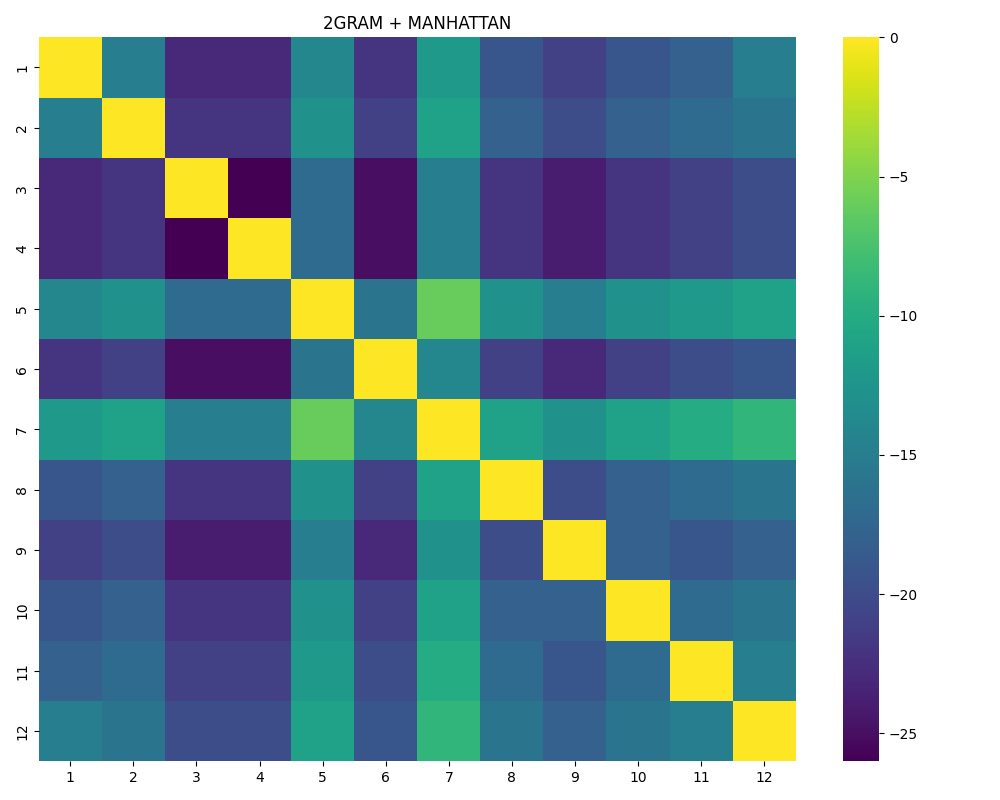

📌 2gram_minkowski.png


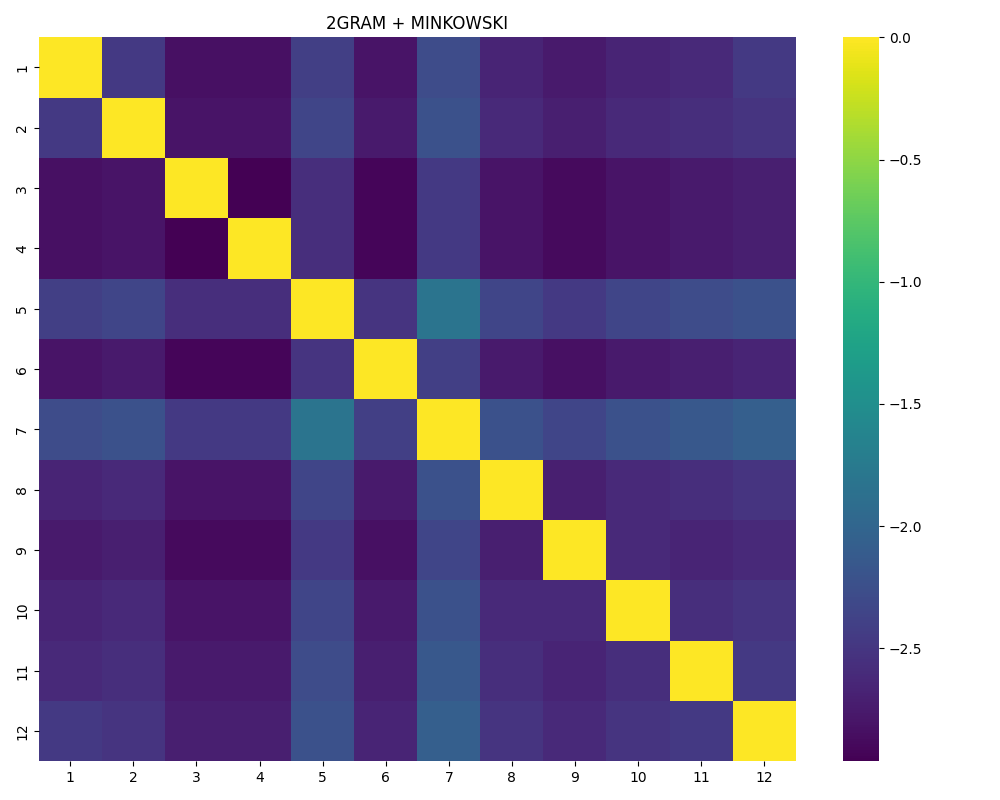

📌 cooccurrence_cosine.png


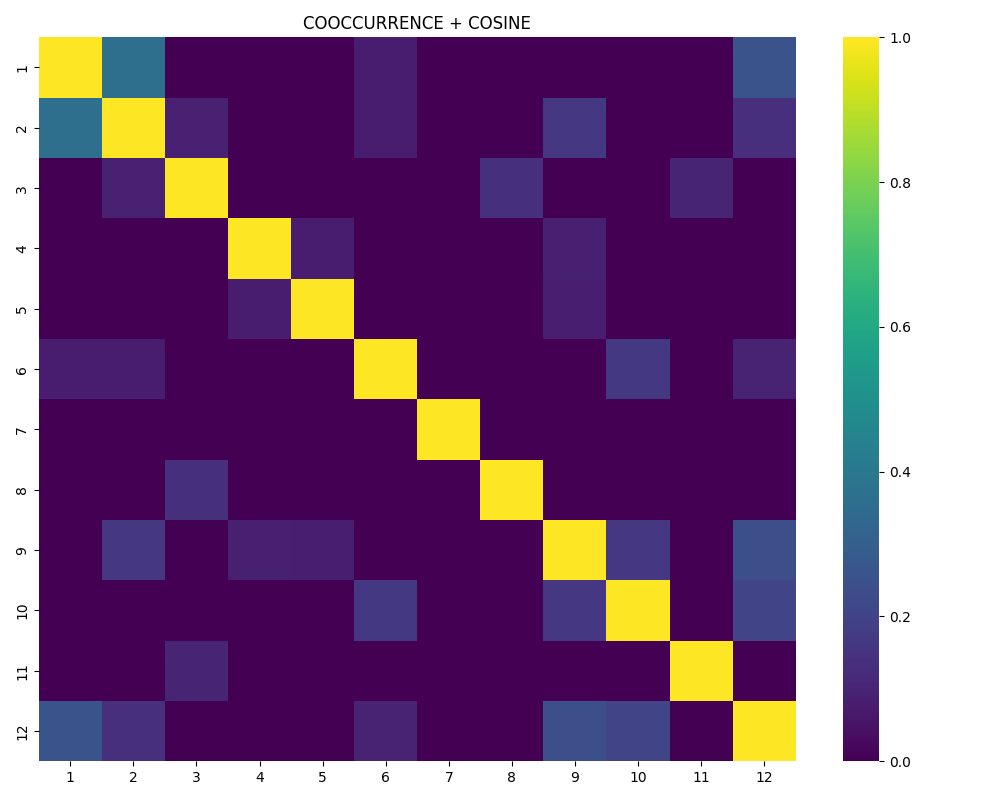

📌 cooccurrence_euclidean.png


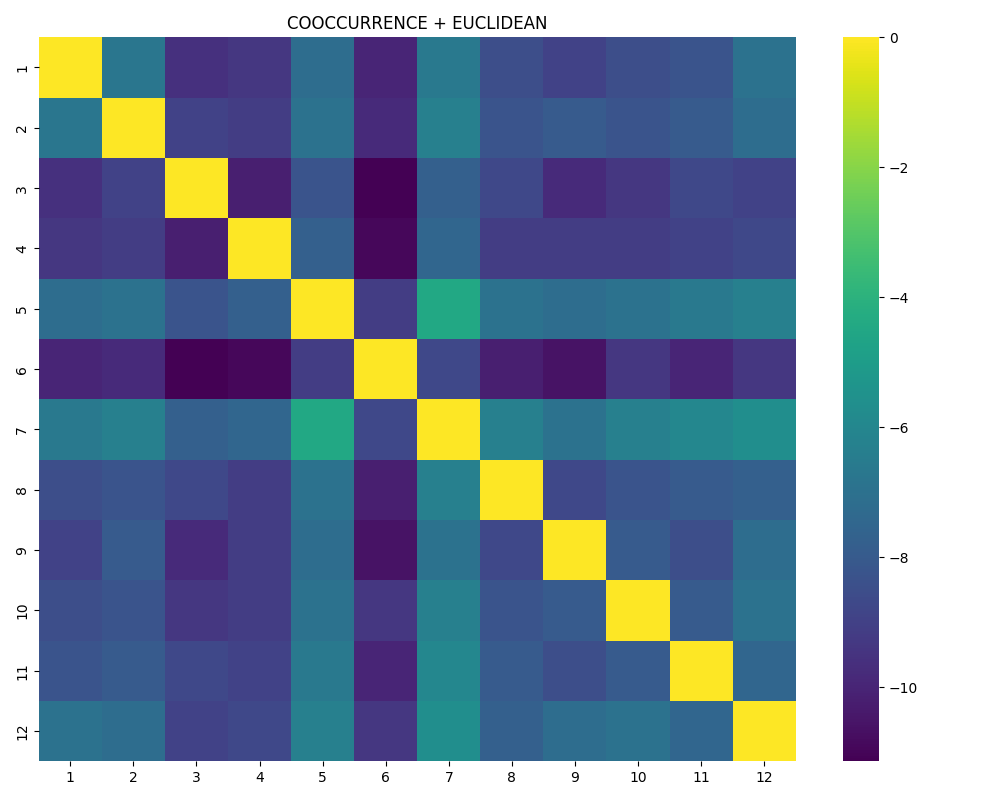

📌 cooccurrence_jaccard.png


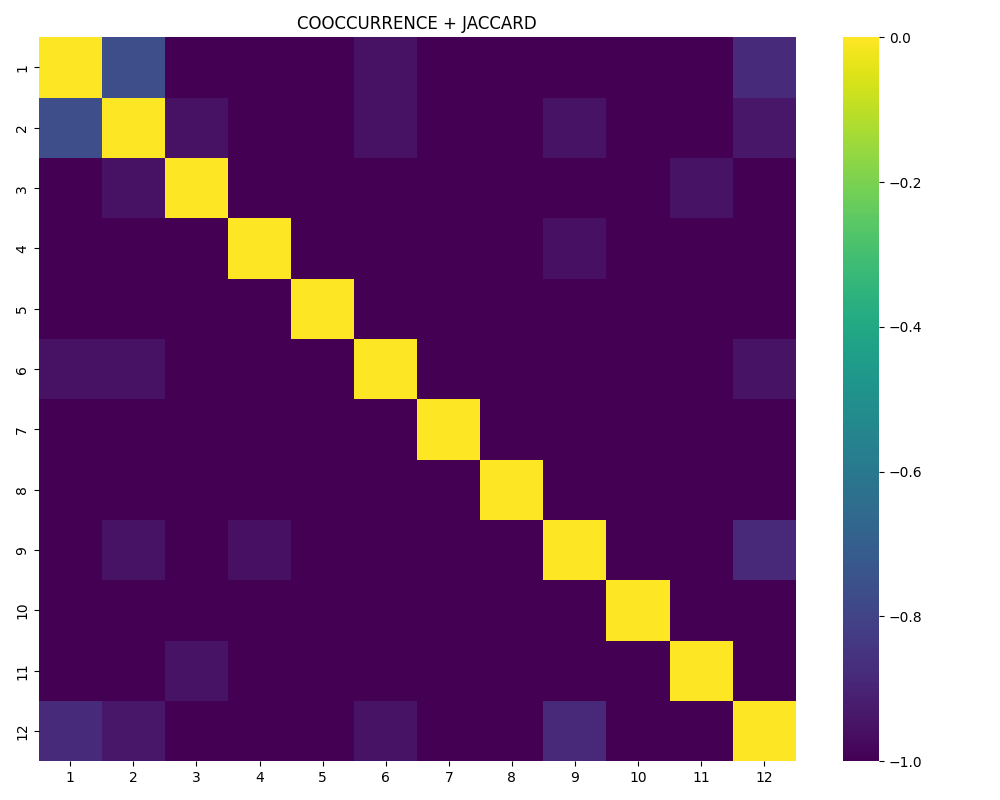

📌 cooccurrence_manhattan.png


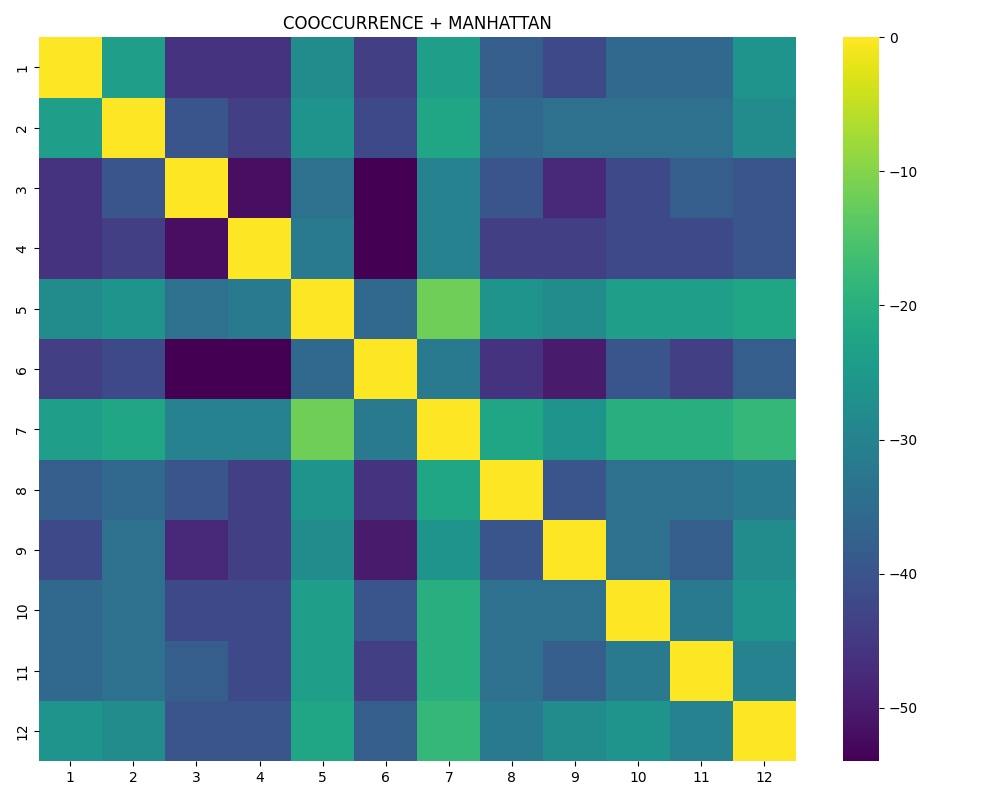

📌 cooccurrence_minkowski.png


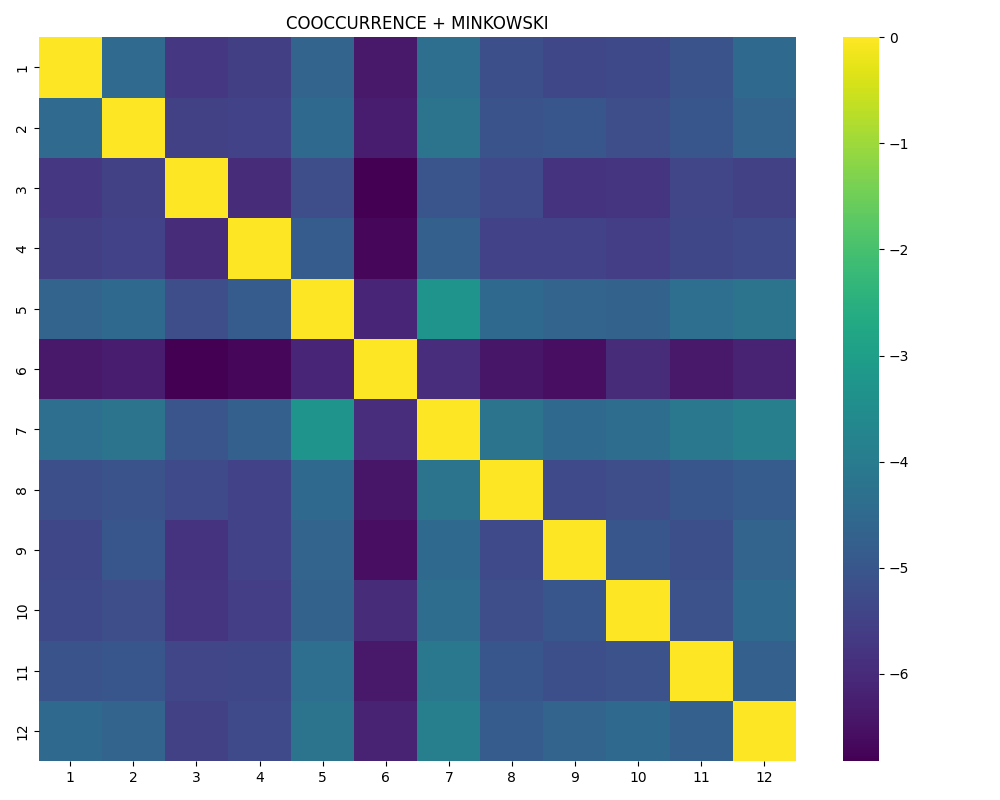

📌 count_cosine.png


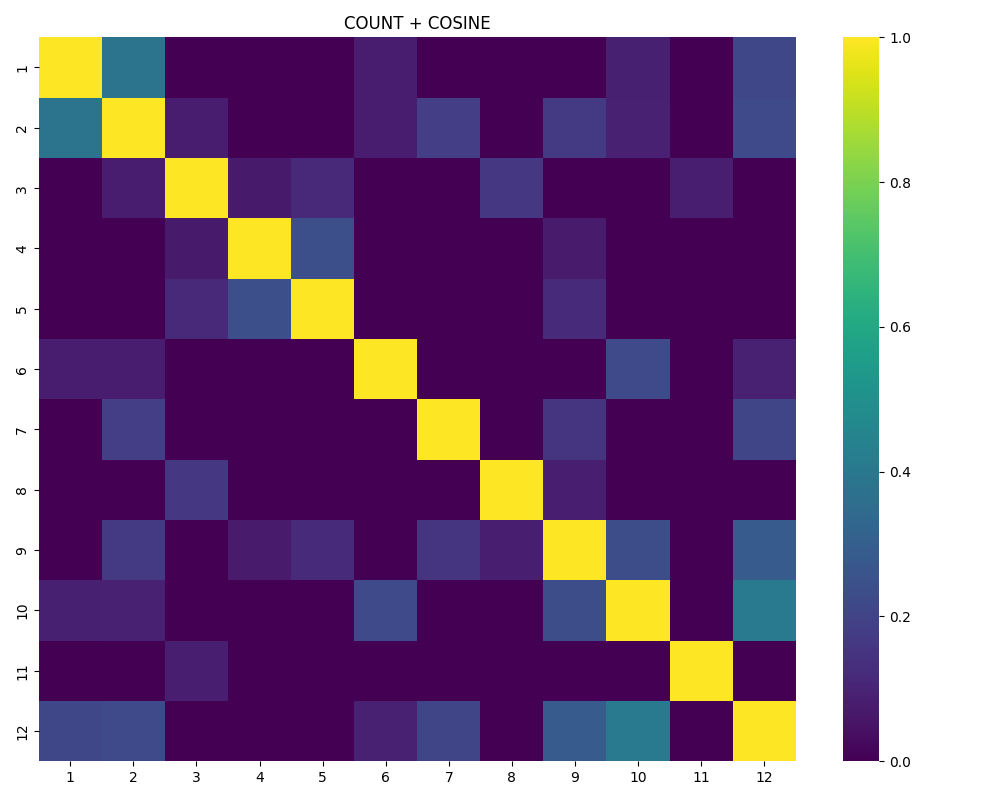

📌 count_euclidean.png


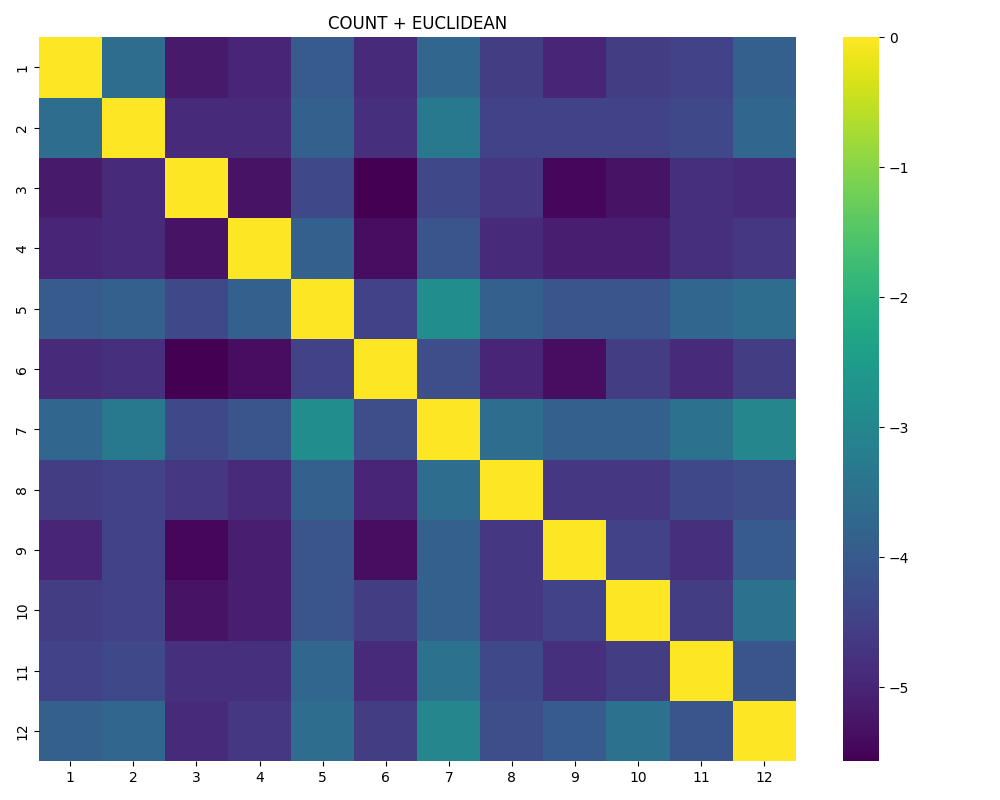

📌 count_jaccard.png


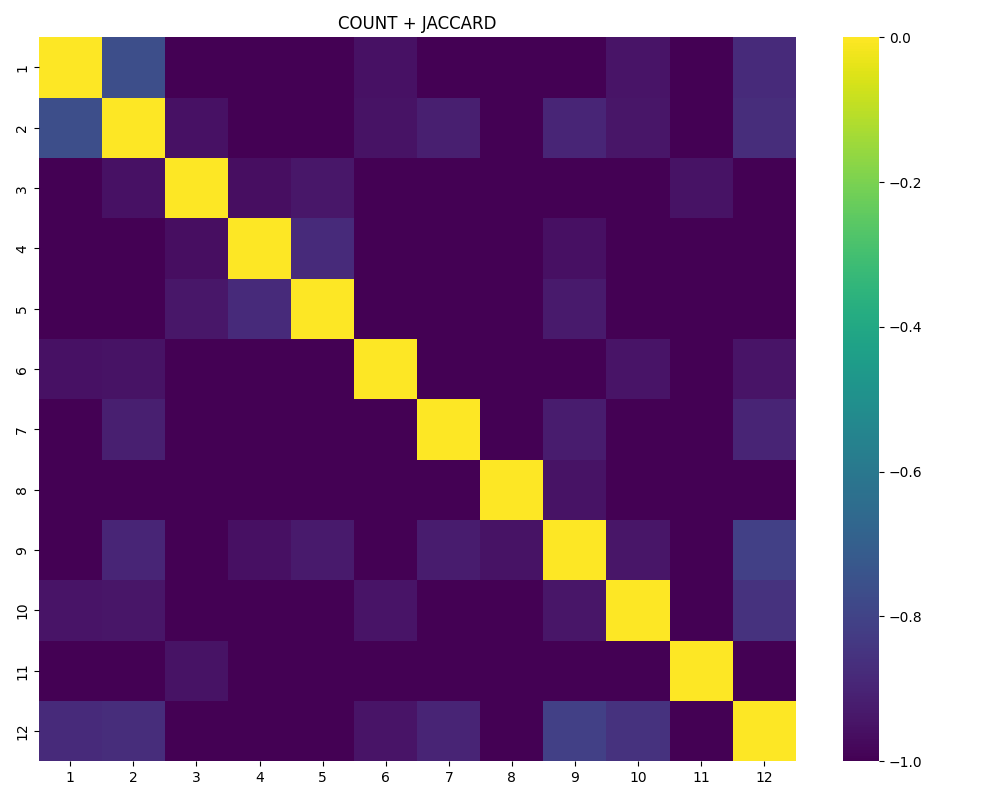

📌 count_manhattan.png


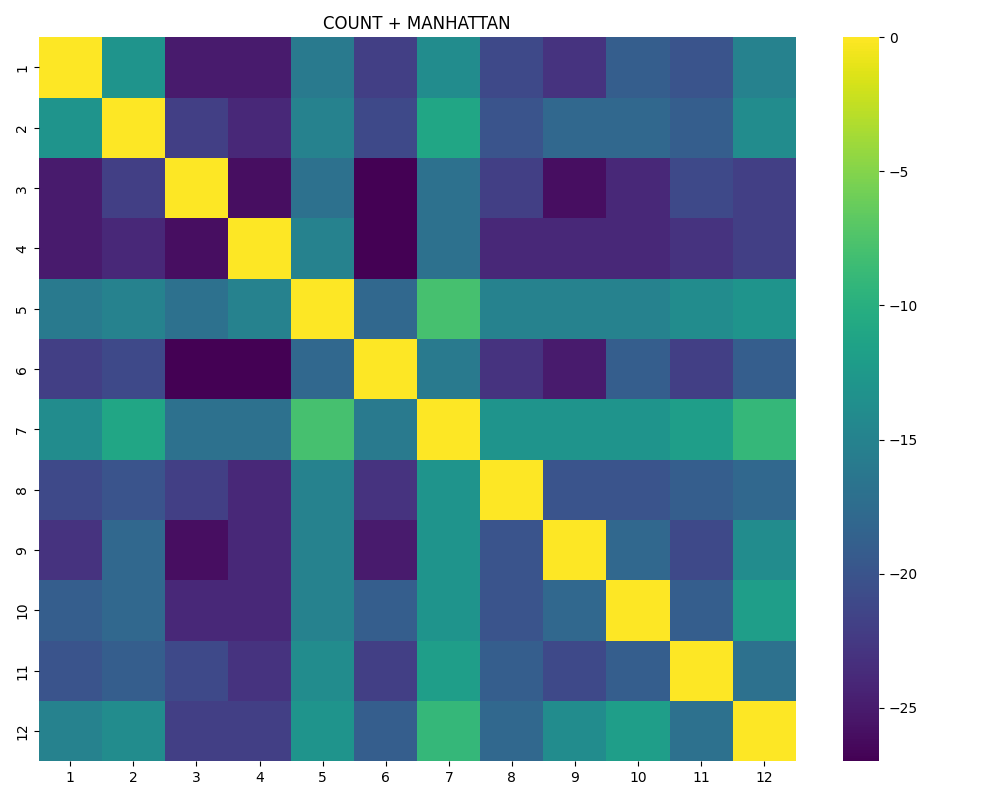

📌 count_minkowski.png


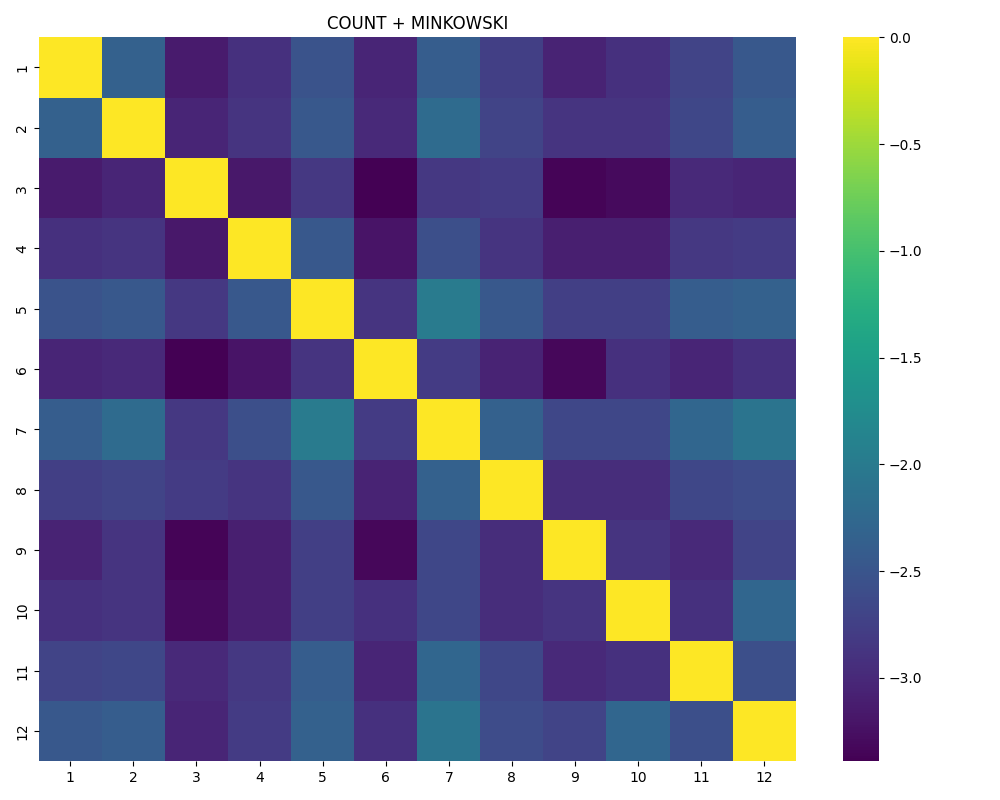

📌 one_hot_cosine.png


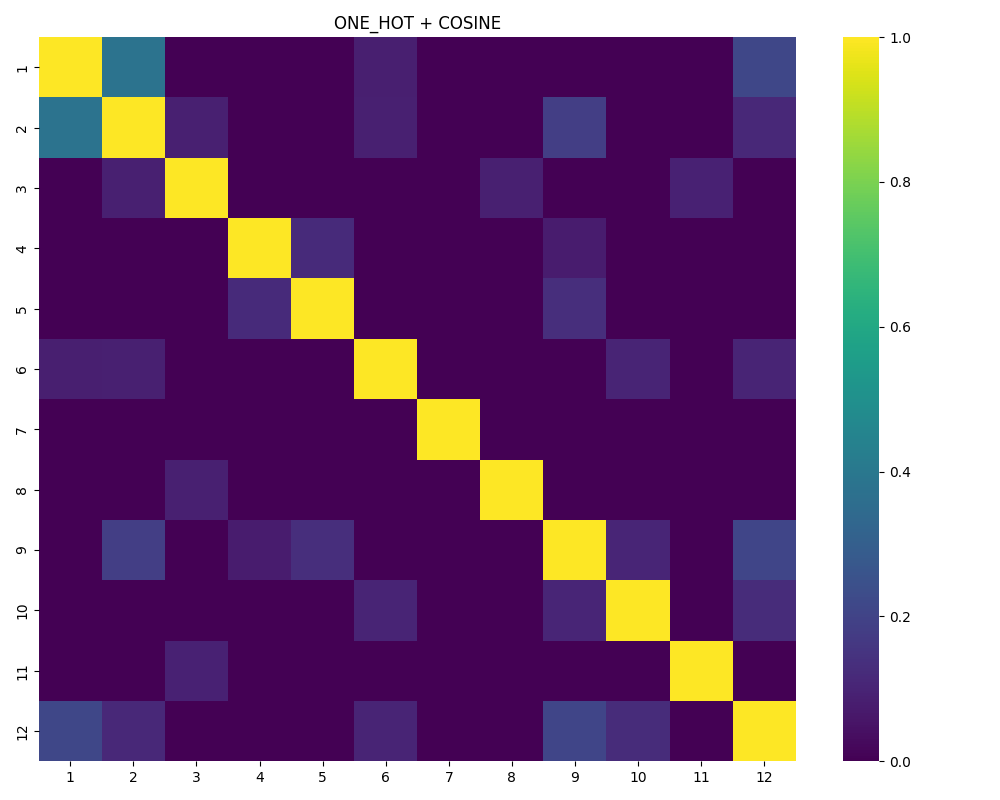

📌 one_hot_euclidean.png


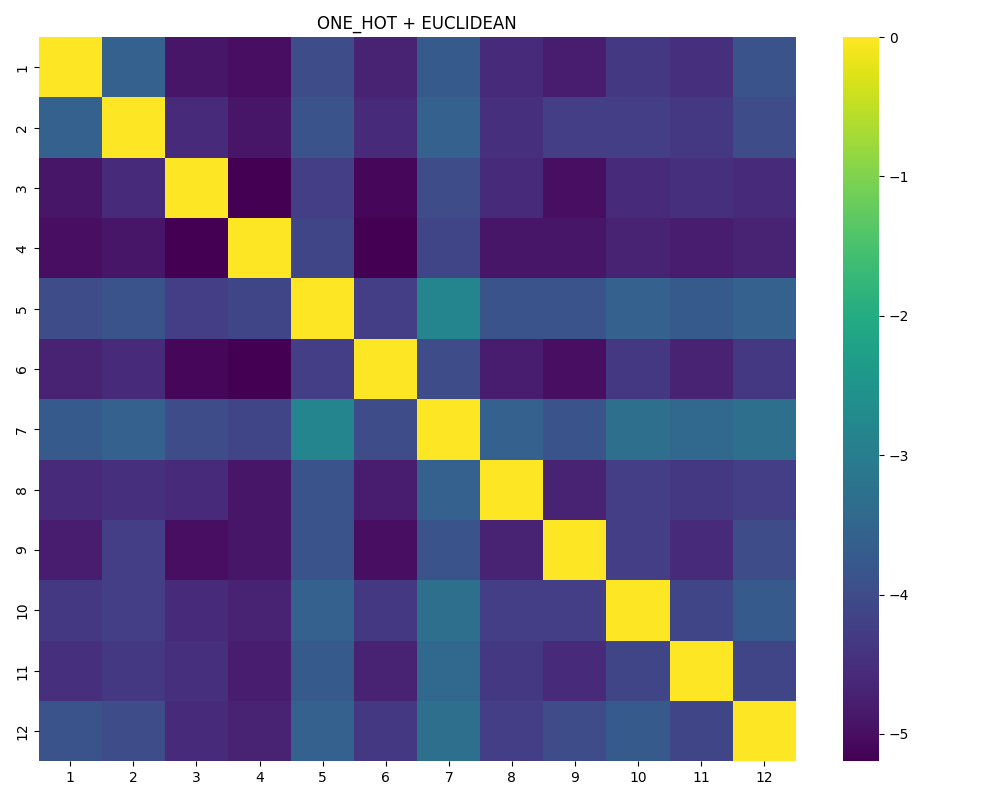

📌 one_hot_jaccard.png


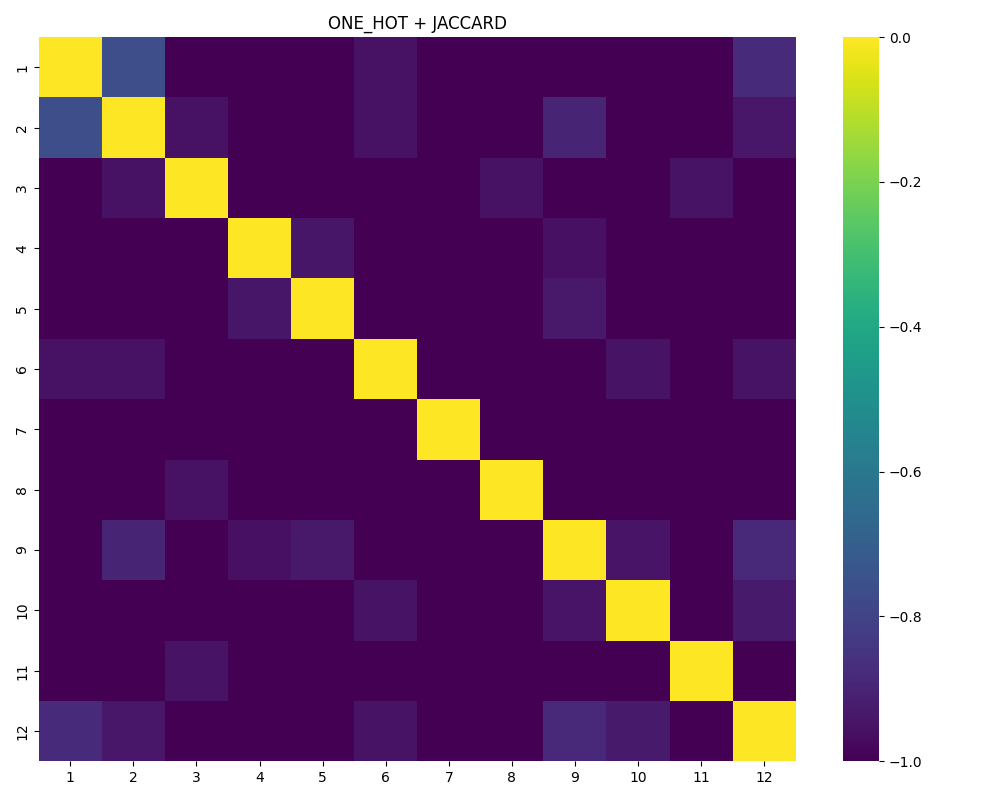

📌 one_hot_manhattan.png


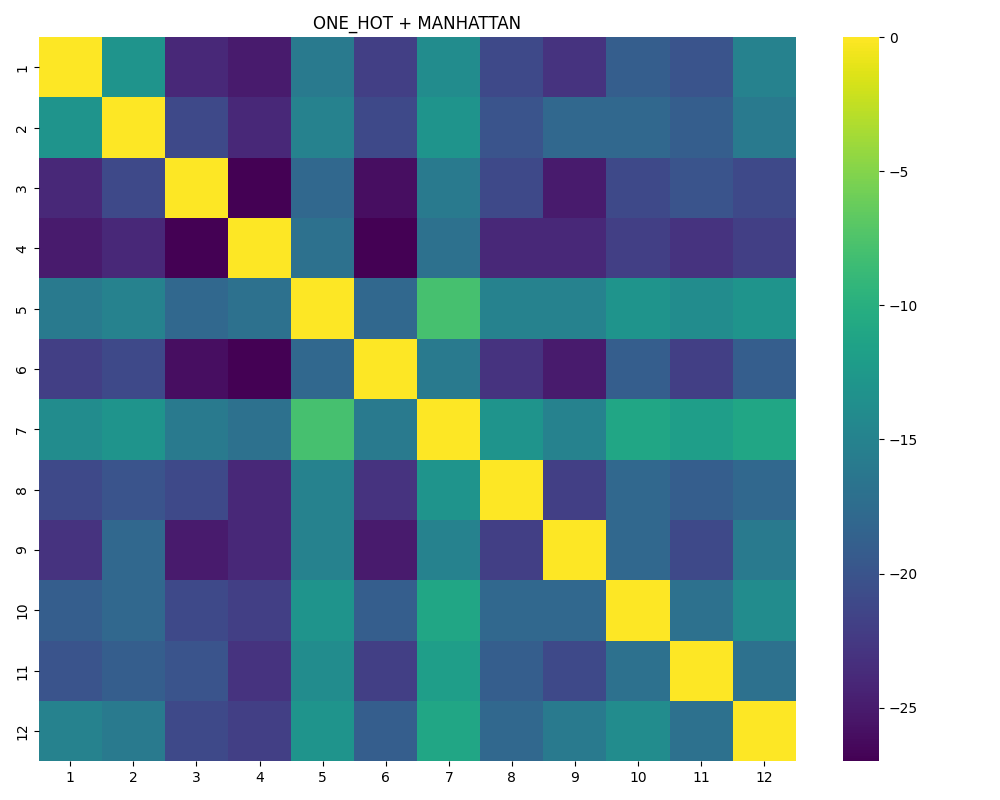

📌 one_hot_minkowski.png


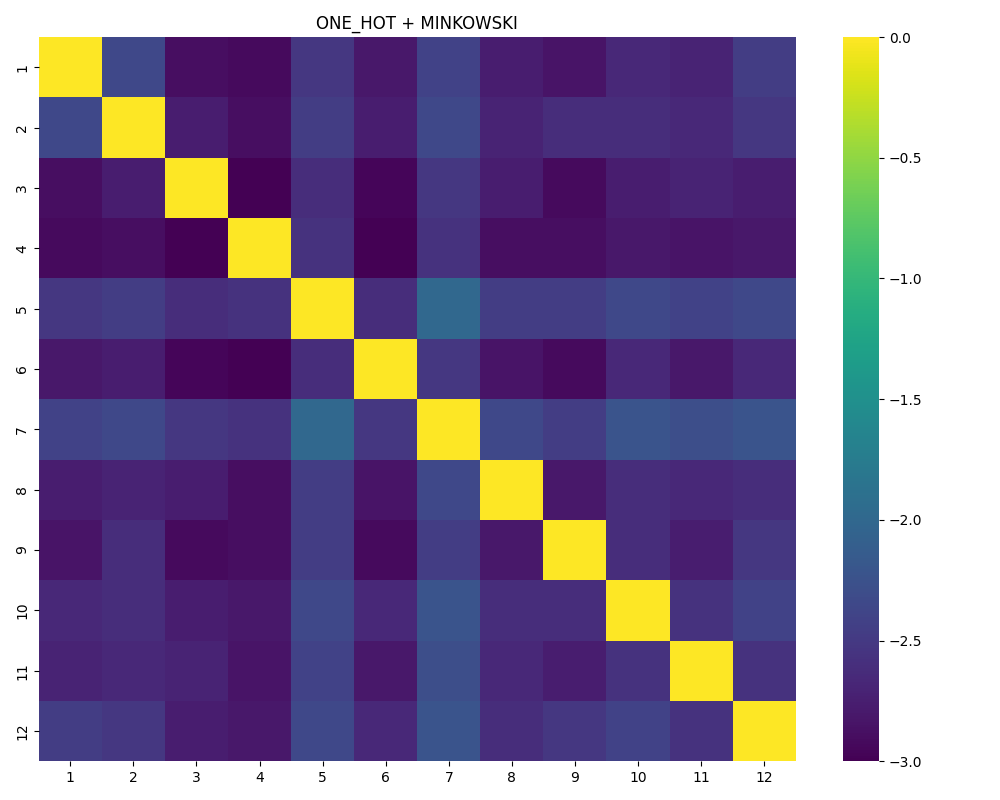

📌 tfidf_cosine.png


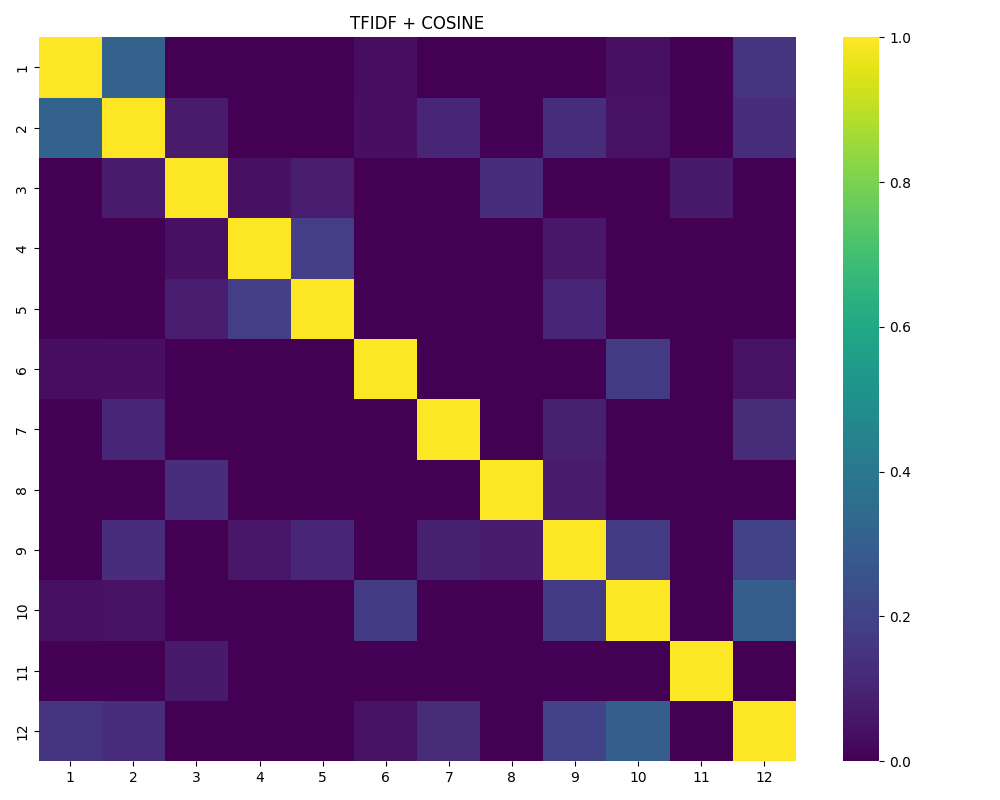

📌 tfidf_euclidean.png


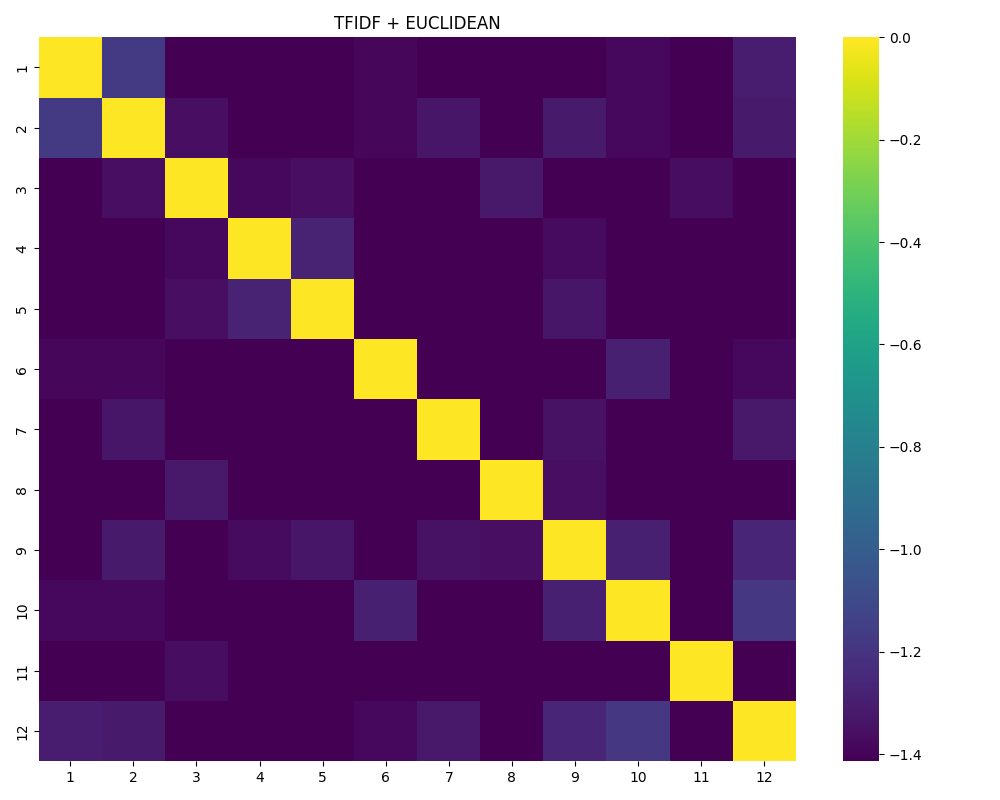

📌 tfidf_jaccard.png


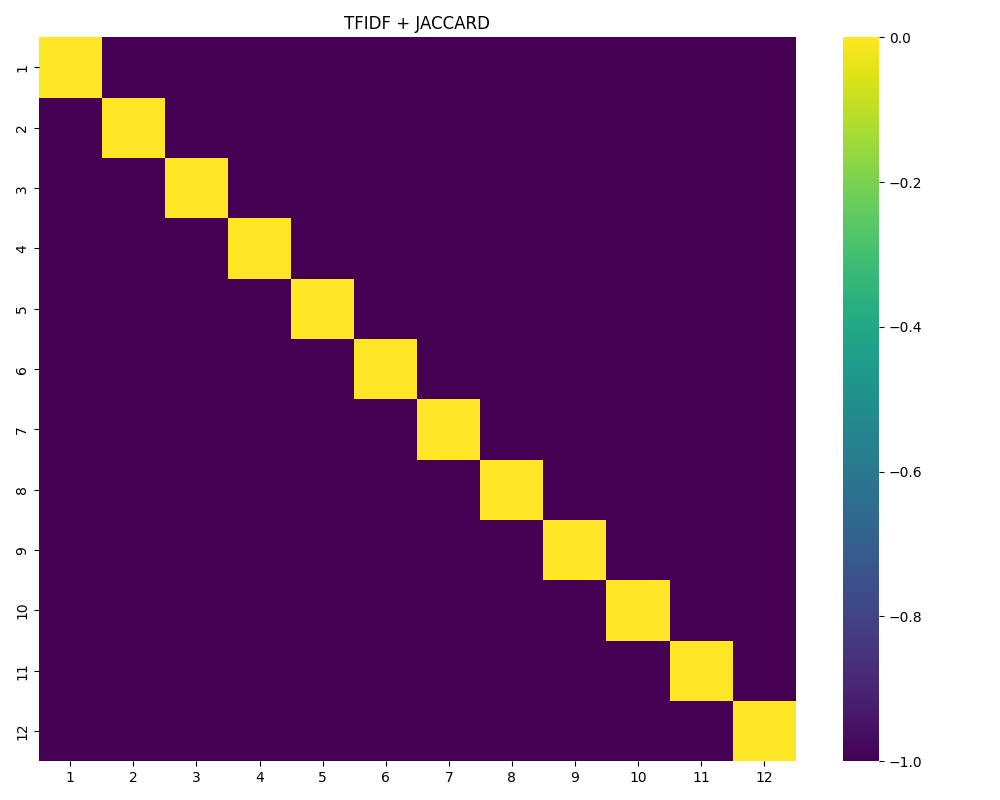

📌 tfidf_manhattan.png


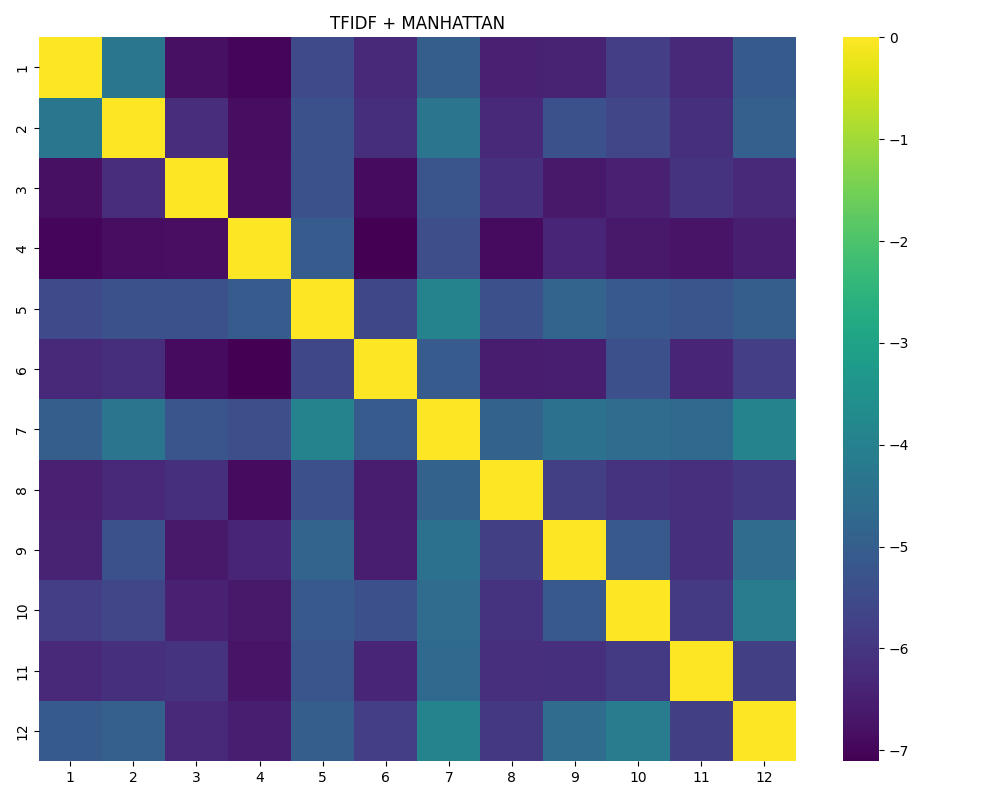

📌 tfidf_minkowski.png


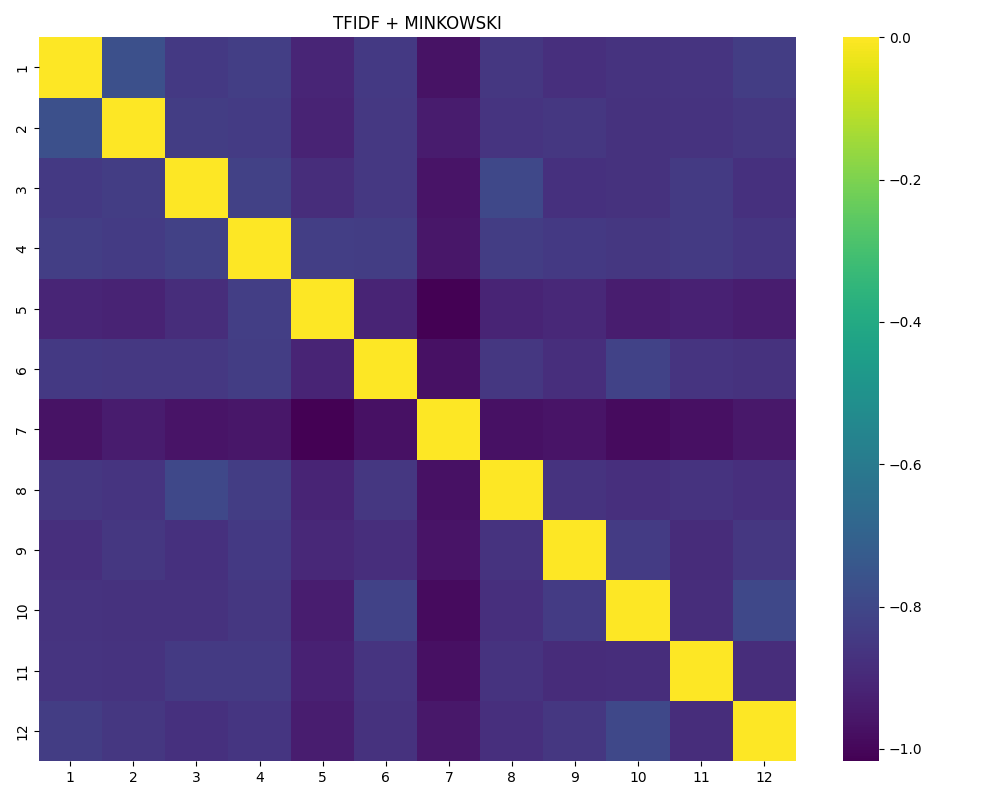

In [ ]:
from IPython.display import Image, display
import glob

heatmap_files = sorted(glob.glob("heatmaps/*.png"))

print(f"🖼️ Exibindo {len(heatmap_files)} mapas de calor...\n")
for file in heatmap_files:
    print(f"📌 {os.path.basename(file)}")
    display(Image(filename=file))